# 實作PGGAN演算法，產生名人臉部
### 程式修改自[High-quality image generation of fashion, celebrity faces](https://pytorch.org/hub/facebookresearch_pytorch-gan-zoo_pgan/)

## 載入相關套件

In [ ]:
from typing import Any

import matplotlib.pyplot as plt
import torch
import torchvision

## 載入預先訓練好的模型

In [ ]:
use_gpu = True if torch.cuda.is_available() or torch.mps.is_available() else False

# trained on high-quality celebrity faces "celebA" dataset
# this model outputs 512 x 512 pixel images
model: Any = torch.hub.load(
    'facebookresearch/pytorch_GAN_zoo:hub', 'PGAN', model_name='celebAHQ-512', pretrained=True, useGPU=use_gpu
)

# this model outputs 256 x 256 pixel images
# model = torch.hub.load('facebookresearch/pytorch_GAN_zoo:hub',
#                        'PGAN', model_name='celebAHQ-256',
#                        pretrained=True, useGPU=use_gpu)

Using cache found in /Users/rikenmi/.cache/torch/hub/facebookresearch_pytorch_GAN_zoo_hub


Average network found !


## 產生圖像

(np.float64(-0.5), np.float64(2057.5), np.float64(515.5), np.float64(-0.5))

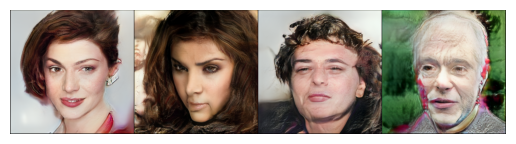

In [3]:
# 產生圖像個數
num_images = 4
# 產生雜訊資料
noise, _ = model.buildNoiseData(num_images)
# 產生圖像
with torch.no_grad():
    generated_images = model.test(noise)

# clamp 使像素值介於 [0, 1] 之間
grid = torchvision.utils.make_grid(generated_images.clamp(min=-1, max=1), scale_each=True, normalize=True)
# permute 設定色彩通道在最後一維
plt.imshow(grid.permute(1, 2, 0).cpu().numpy())
plt.axis('off')